# Example for bssunfold package with Bunki, BunkiUT, and Sandii methods

This notebook demonstrates the following unfolding methods:
- `unfold_bunki`: Bunki iterative method
- `unfold_bunkiut`: BunkiUT variant
- `unfold_sandii`: Sandii method

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Setup detector and reference spectrum

In [8]:
det = Detector(RF_LANL)
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])

## Apply various unfolding methods

In [9]:
# Bunki method
result_bunki = det.unfold_bunki(readings)

# BunkiUT method
result_bunkiut = det.unfold_bunkiut(readings)

# Sandii method
result_sandii = det.unfold_sandii(readings)

## Plot comparison of results

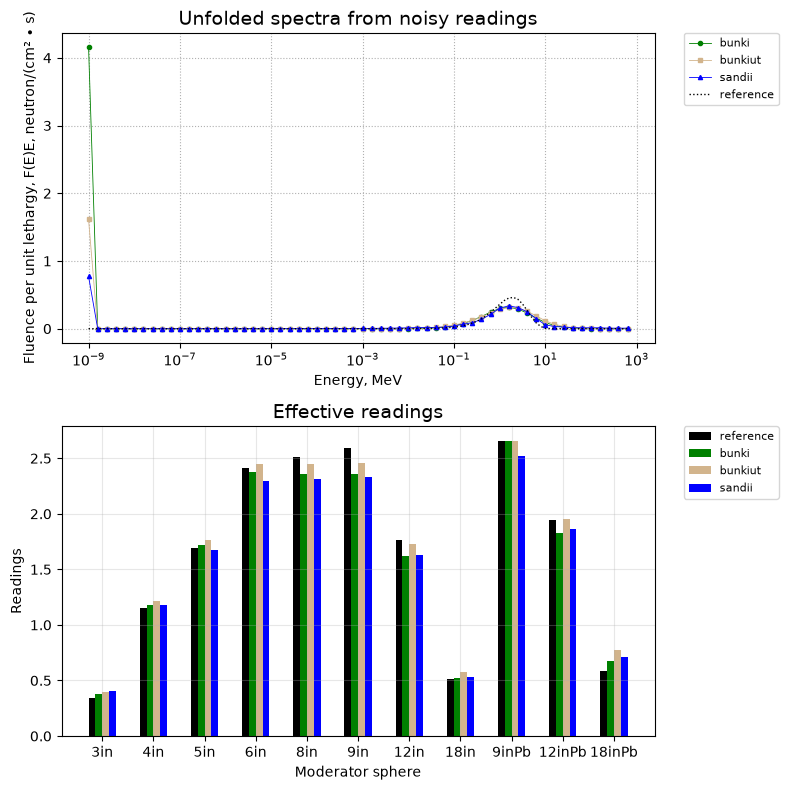

In [10]:
results = {
    "bunki": result_bunki,
    "bunkiut": result_bunkiut,
    "sandii": result_sandii,
}

fig, ax = plot_comparison(
    results=results,
    readings=readings,
    reference_spectrum=reference_spectrum[["E_MeV", "ISO_ref_Cf252"]],
)

## Spectrum plots for each method

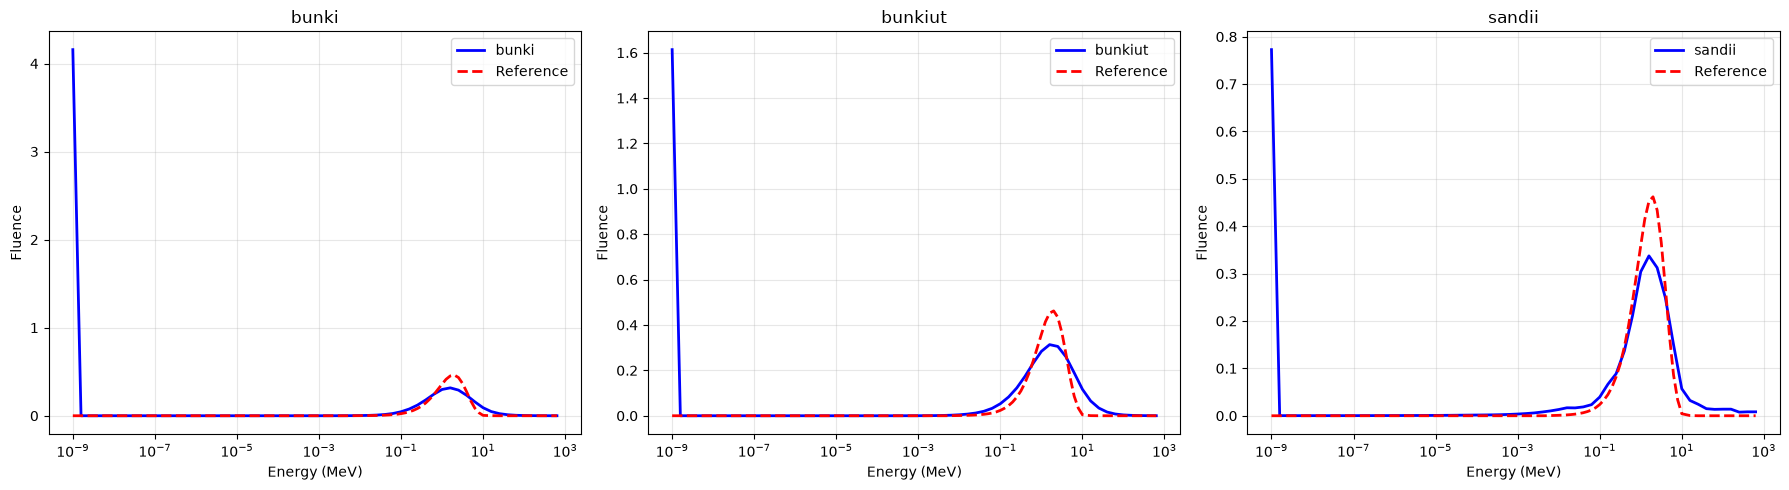

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

method_names = list(results.keys())

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(det.E_MeV, result['spectrum'], 'b-', label=f'{name}', linewidth=2)
    ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', label='Reference', linewidth=2)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Fluence')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('linear')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated three iterative unfolding methods:

1. **Bunki**: Basic iterative unfolding approach
2. **BunkiUT**: Updated variant of the Bunki method
3. **Sandii**: Alternative iterative technique

These methods provide different approaches to solving the neutron spectrum unfolding problem through iterative refinement.